## t-SNE (t-distributed Stochastic Neighbor Embedding):

t-SNE (t-Distributed Stochastic Neighbor Embedding) is a dimensionality reduction technique designed specifically for visualizing high-dimensional data in 2D or 3D. It's one of the most popular tools for exploring and understanding the structure of complex datasets.

#### How it works

t-SNE converts high-dimensional distances between data points into probabilities, then creates a low-dimensional map that preserves the original neighborhood structure. The key steps:

1. **Compute similarities in high-dimensional space**: For each point, t-SNE calculates how similar it is to every other point based on Gaussian distributions
2. **Define similarities in low-dimensional space**: It maps points to 2D/3D and computes new similarities using Student's t-distribution (hence the "t" in t-SNE)
3. **Optimize via gradient descent**: It iteratively adjusts point positions to make the low-dimensional similarities match the high-dimensional similarities

#### Key characteristics

- **Local structure preservation**: t-SNE excels at preserving local neighborhoods—points close together in high dimensions stay close in the visualization
- **Non-linear**: Unlike PCA, t-SNE can capture non-linear relationships
- **Stochastic**: Results vary slightly between runs (can add a random seed for reproducibility)
- **Computationally expensive**: Scales poorly to very large datasets; typically used for < 100K points
- **Not ideal for new data**: t-SNE can't easily project new unseen points onto an existing embedding

#### When to use it

- Exploratory data analysis to spot clusters and patterns
- Visualizing embeddings (word vectors, image features, etc.)
- Understanding if your data has natural groupings before clustering

#### When NOT to use it

- When you need to project new data points (it's not a true model)
- With very large datasets (consider alternatives like UMAP or PaCMAP)
- When you need interpretable axes (t-SNE axes have no meaning)
- For production pipelines requiring reproducibility

#### Comparison with alternatives

- **PCA**: Faster, linear, preserves global structure, axes are interpretable
- **UMAP**: Faster than t-SNE, better at preserving both local and global structure
- **Autoencoders**: Can generalize to new data, more flexible
#
---

### **What is perplexity:**

Perplexity in t-SNE (t-distributed Stochastic Neighbor Embedding) is a **hyperparameter that acts as a target for the effective number of nearest neighbors each point considers when calculating local densities**.

Mathematically, it is related to the Shannon entropy of the conditional probability distribution $P_{j|i}$ (the probability that point $i$ would pick point $j$ as its neighbor). The relationship is defined as:

$$\text{Perplexity}(P_i) = 2^{H(P_i)}$$

where $H(P_i)$ is the Shannon entropy of the distribution.

**Key Implications:**

*   **Local vs. Global Structure:** 
    *   **Low Perplexity:** Focuses on very local variations. The algorithm considers only a few immediate neighbors, which can result in "clumpy" or fragmented clusters that may be artifacts of noise.
    *   **High Perplexity:** Focuses on more global structure. The algorithm considers a larger neighborhood, resulting in smoother, more cohesive clusters, but it may merge distinct groups if set too high.
*   **Density Estimation:** It essentially determines the "width" (variance) of the Gaussian kernels used to measure similarities in the high-dimensional space.
*   **Default Value:** In `sklearn.manifold.TSNE`, the default value is **30**.

**Practical Rule of Thumb:**
Perplexity should generally be scaled with the size of the dataset. For very large datasets, a higher perplexity may be required to capture the global manifold structure, though values typically range between 5 and 50.

### **Perplexity is the number of neighbors:**

Perplexity is a proxy for the number of nearest neighbors that each point considers when calculating similarity. 

It determines the balance between local and global aspects of your data:

*   **Low Perplexity:** The algorithm focuses on a very small number of neighbors. This emphasizes local variations and can create many small, disconnected clusters.
*   **High Perplexity:** The algorithm considers a larger number of neighbors. This emphasizes the global structure and produces smoother, more continuous clusters.

If the perplexity is too low, the visualization may look like a scattered "cloud" of points. If it is too high, the algorithm may fail to separate distinct clusters because it is trying to account for too many distant points simultaneously.
#
---

### **How to choose the learning_rate:** 

In modern implementations of t-SNE (including `scikit-learn`), the learning rate is typically determined by the size of your dataset rather than a fixed constant.

#### 1. The Modern Standard: `learning_rate='auto'`
The current best practice is to set `learning_rate='auto'`. 
In `scikit-learn`, this uses the formula:
$$\text{learning\_rate} = \frac{N}{12}$$
*(where $N$ is the number of samples)*

This ensures that as your dataset grows, the step size increases proportionally to prevent the points from getting "stuck" in a dense mass.

#### 2. Typical Numerical Ranges
If you are manually setting the value, the range depends on your data size:

*   **Small Datasets ($N < 500$):** Values between **10 and 100** are common.
*   **Medium Datasets ($N \approx 1,000$ to $10,000$):** Values between **200 and 1,000** are standard.
*   **Large Datasets ($N > 10,000$):** Values can exceed **1,000 or even 2,000**.

#### 3. How to diagnose if your learning rate is wrong
You can tell if your learning rate is incorrect by looking at the resulting plot:

| If the plot looks like... | The learning rate is likely... |
| :--- | :--- |
| **A dense, uninformative "ball" or "clump"** | **Too low.** The points didn't have enough "energy" to move away from each other. |
| **A chaotic, exploded mess (points far apart)** | **Too high.** The points "overshot" their optimal positions and flew away. |
| **Clear, distinct clusters** | **Correct.** The optimization successfully balanced local and global forces. |

**Pro-tip:** If you are struggling to get a good visualization, instead of guessing a number, try using `learning_rate='auto'` first. If that fails, try increasing it by factors of 10 (e.g., 200 $\rightarrow$ 2000 $\rightarrow$ 20000).

### **Examples:**

In [21]:
from sklearn.manifold import TSNE
from sklearn.datasets import make_blobs
import numpy as np
import matplotlib.pyplot as plt

import warnings
warnings.filterwarnings('ignore', category=RuntimeWarning)

In [22]:
# Create 3 distinct clusters in 100-dimensional space
n_samples = 1000
n_features = 100
n_clusters = 3
random_state = 42
 
np.random.seed(random_state)
 
# Generate clustered data
X, y = make_blobs(
    n_samples=n_samples,
    n_features=n_features,
    centers=n_clusters,
    cluster_std=2.0,
    random_state=random_state
)
 
print(f"Data shape: {X.shape}")
print(f"Number of clusters: {len(np.unique(y))}")
print(f"Features per sample: {n_features}")

Data shape: (1000, 100)
Number of clusters: 3
Features per sample: 100


In [23]:
tsne = TSNE(
    n_components=2,
    random_state=42,
    perplexity=n_samples/12,
    max_iter=1000,
    verbose=1
)

In [24]:
X_embedded = tsne.fit_transform(X)
print(f'Embedded data shape: {X_embedded.shape}')

[t-SNE] Computing 251 nearest neighbors...
[t-SNE] Indexed 1000 samples in 0.000s...
[t-SNE] Computed neighbors for 1000 samples in 0.014s...
[t-SNE] Computed conditional probabilities for sample 1000 / 1000
[t-SNE] Mean sigma: 7.083962
[t-SNE] KL divergence after 250 iterations with early exaggeration: 45.184235
[t-SNE] KL divergence after 1000 iterations: 1.047984
Embedded data shape: (1000, 2)


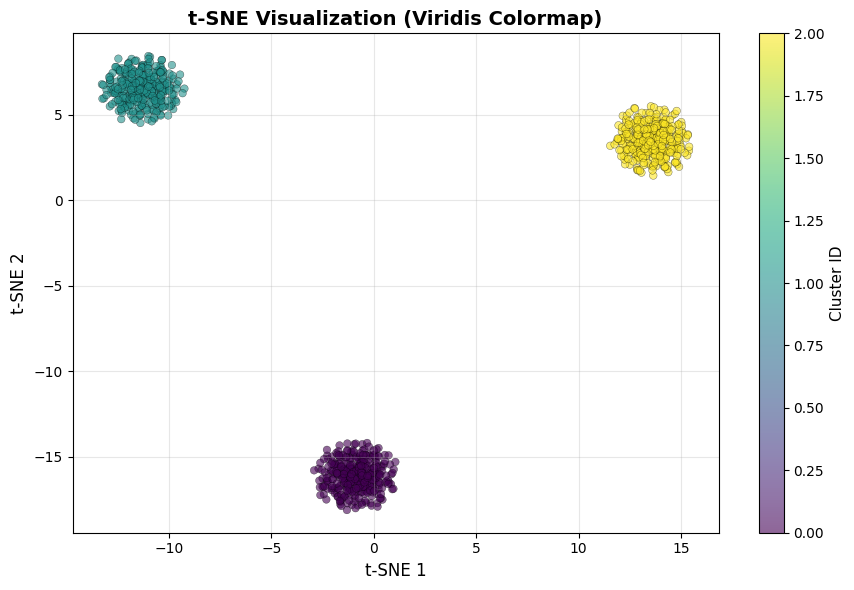

In [25]:
fig, axes = plt.subplots(1, 1, figsize=(9, 6))

# Plot 1: Density heatmap style
ax = axes
scatter = ax.scatter(
    X_embedded[:, 0],
    X_embedded[:, 1],
    c=y,
    cmap='viridis',
    alpha=0.6,
    s=30,
    edgecolors='black',
    linewidth=0.3
)
 
ax.set_xlabel('t-SNE 1', fontsize=12)
ax.set_ylabel('t-SNE 2', fontsize=12)
ax.set_title('t-SNE Visualization (Viridis Colormap)', fontsize=14, fontweight='bold')
cbar = plt.colorbar(scatter, ax=ax)
cbar.set_label('Cluster ID', fontsize=11)
ax.grid(True, alpha=0.3)
 
plt.tight_layout()
plt.show()

### **t-SNE can lose information:**

**t-SNE can lose information**, and understanding this tradeoff is important for your work.

#### What information gets lost

When t-SNE reduces from high-dimensional space (e.g., 100 features) to 2D/3D, it **must discard information** because you're compressing vastly:

1. **Global structure**: t-SNE prioritizes local neighborhoods, so long-range relationships between distant clusters may not be preserved
2. **Quantitative distances**: The actual distances between points in the embedding are **not meaningful**. A point that's far away isn't necessarily "more different"—it's just in a different local neighborhood
3. **Linear relationships**: If your data has linear structure (like PCA can capture), t-SNE may obscure it
4. **Absolute geometry**: The shape and size of clusters in the 2D plot don't reflect their true high-dimensional properties

#### Visual example

```python
# Two different high-dimensional configurations 
# could produce IDENTICAL t-SNE plots:

# Config A: Clusters tightly packed in one corner of 100D space
# Config B: Clusters spread across all of 100D space

# Both might look the same in t-SNE if local neighborhoods match!
```

#### Critical limitations for your use case

For fraud detection on IEEE-CIS, this matters:

| What t-SNE preserves | What it loses |
|---|---|
| Local cluster structure | Global scale relationships |
| Relative position of similar transactions | Actual feature distances |
| Separation between fraud/legitimate patterns | Interpretability of axes |
| Neighborhood relationships | Can be used for modeling |

#### What you should NOT do

❌ **Don't use t-SNE embeddings as features** for your XGBoost/LightGBM models (you'll lose information)

❌ **Don't interpret distances** as "how different" two transactions are

❌ **Don't assume** the visualization captures everything important in your data

#### What you SHOULD do

✅ **Use t-SNE for exploration only**: "Do fraudulent transactions cluster together? Are there subclusters?"

✅ **Combine with other methods**:
```python
# Good approach: triangulate insights
- PCA for global structure
- t-SNE for local structure  
- UMAP for both (better balance)
- Silhouette scores for cluster quality
```

✅ **Validate findings** with statistical tests or your actual model performance

✅ **Use original features** for your ML models, not the t-SNE projection

#### Better alternative for your fraud work

Consider **UMAP** instead—it preserves both local AND global structure much better:

```python
from umap import UMAP

umap = UMAP(
    n_components=2,
    n_neighbors=15,      # Local structure
    min_dist=0.1,        # Spread, it sets the minimum distance taht UMAP tries to maintain between points in the 2D/3D visualization.
    metric='euclidean'
)
X_embedded = umap.fit_transform(X_scaled)

# UMAP also preserves more "truthful" distances
# and generalizes to new data (t-SNE can't)
```

### Quick comparison

| Method | Local structure | Global structure | Can project new data | Speed |
|---|---|---|---|---|
| **PCA** | Poor | Excellent | Yes | Very fast |
| **t-SNE** | Excellent | Poor | No | Slow |
| **UMAP** | Excellent | Good | Yes | Fast |
#
#
---

### **What t-SNE is Used For:**

t-SNE is primarily a **visualization and exploratory data analysis tool**. Here are the main use cases:

#### 1. **Exploratory Data Analysis (EDA)**

Understand the structure of your data visually:

```python
# "Do my data points naturally cluster?"
# "Are there obvious separations between classes?"

tsne = TSNE(n_components=2, random_state=42)
X_2d = tsne.fit_transform(X)

plt.scatter(X_2d[:, 0], X_2d[:, 1], c=y)  # Color by class
plt.show()
```

**Questions it answers:**
- Are fraud and legitimate transactions separable?
- Are there natural groupings in the data?
- Are there outliers or anomalies?


#### 2. **Understanding Model Embeddings**

Visualize what your neural networks learn:

```python
# Extract embeddings from a deep learning model
embeddings = model.predict(X)  # Shape: (n_samples, 256)

# Visualize in 2D
tsne = TSNE(n_components=2)
embedded_2d = tsne.fit_transform(embeddings)

# See if the model learned meaningful representations
plt.scatter(embedded_2d[:, 0], embedded_2d[:, 1], c=y)
```

**Example for you**: 
- See what your XGBoost learned in its leaf embeddings
- Understand if similar transactions cluster together


#### 3. **Cluster Validation**

Check if your clustering algorithm worked:

```python
from sklearn.cluster import KMeans

# Do k-means clusters look reasonable?
clusters = KMeans(n_clusters=3).fit_predict(X)

tsne = TSNE(n_components=2)
X_2d = tsne.fit_transform(X)

plt.scatter(X_2d[:, 0], X_2d[:, 1], c=clusters, cmap='viridis')
plt.title('Do these clusters make sense?')
plt.show()
```


#### 4. **Feature Space Analysis**

Understand high-dimensional feature relationships:

```python
# Your IEEE-CIS features: 100+ dimensions
# Question: "Are my engineered features meaningful?"

tsne = TSNE(n_components=2, perplexity=30)
features_2d = tsne.fit_transform(X_features)

# Color by fraud label
plt.scatter(features_2d[~fraud_mask, 0], features_2d[~fraud_mask, 1], 
           label='Legitimate', alpha=0.5)
plt.scatter(features_2d[fraud_mask, 0], features_2d[fraud_mask, 1], 
           label='Fraud', alpha=0.7, c='red')
plt.legend()
plt.title('Feature space: Are frauds visually separable?')
plt.show()
```


#### 5. **Identifying Data Quality Issues**

Spot problems in your dataset:

```python
tsne = TSNE(n_components=2)
X_2d = tsne.fit_transform(X)

# Outliers appear isolated
# Duplicates appear on top of each other
# Mislabeled data appears in wrong clusters

plt.scatter(X_2d[:, 0], X_2d[:, 1])
plt.title('Any weird clusters or isolated points?')
plt.show()
```


#### What t-SNE is NOT used for

❌ **Feature engineering** - Don't use t-SNE embeddings as features for models (information loss)

❌ **Dimensionality reduction** - It's for visualization, not preprocessing

❌ **Projecting new data** - Can't apply t-SNE to unseen data points

❌ **Interpretable axis analysis** - t-SNE axes have no meaning

❌ **Production pipelines** - Too slow and non-deterministic
